# Bayesian Inference for Systems of Elementary Reactions

This notebook runs Bayesian parameter inference on an enzyme kinetics ODE model and generates diagnostic plots. It is **Step 2 of 2** — run `guided_solver_config_builder_FabD.ipynb` first to generate the required `solver_params.json` configuration file.

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from GitHub Copilot (Claude Sonnet 4.6)*

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../Utilities")

from pathlib import Path
import json
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import yaml
import preliz as pz

from effective_parameter_limits import evaluate_effective_parameter_limits
from experiment_framework import load_experiment_bundle
from inference_runner import (
    get_free_parameter_names,
    run_bayesian_inference,
    summarize_inference_metrics,
 )
from inference_plotting import (
    plot_diffusion_feasible_parameter_family,
    plot_diffusion_feasible_parameter_marginals,
    plot_parameter_marginals,
    plot_posterior_trace_diagnostics,
    plot_predictive,
    plot_priors,
)
from reaction_model_builder import build_ode_system_from_reactions

Total JAX local devices initialized: 8


## Step 2: Configure and Run

Set the key variables below, then run this cell.

| Variable | Value | Effect |
|---|---|---|
| `use_existing_results` | `False` | **Run full inference** — samples prior then posterior (~10–30 min depending on hardware) |
| `use_existing_results` | `True` | **Load saved results** — skips sampling and goes straight to plotting (requires a previous run) |
| `folder_name` | `"FabD kon inference"` | Folder used to find the solver JSON and organize reactions, data, calculation files, and results |

> **Paths:** The solver params JSON sets `path_base` to the Python Model home directory. Reaction, data, calculation-module, and output paths are stored relative to that home directory.


=== Experiment Summary ===
Calculation module: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Calculation Files/FabD/FabD_calculations.py
Datasets loaded: 2
Unique initial conditions: 8
Unique simulation times: 14
  - conc_vs_final_C3_MalACP: type='endpoint', observables=['MalACP (uM)'], noise='relative_mean', points=8, init=[FabD<-FabD (uM), C3_MalCoA<-C3_MalCoA (uM), ACP<-ACP (uM)], columns=[MalACP (uM)->C3_MalACP (uM)]
  - time_vs_C3_MalACP: type='timeseries', observables=['MalACP (uM)'], noise='relative_mean', points=14, init=[FabD<-override, C3_MalCoA<-override, ACP<-override], columns=[MalACP (uM)->C3_MalACP (uM)]

=== Sampling ===
Running prior predictive sampling...


Sampling: [a1, b1, b2, b3]


Running posterior MCMC sampling...


Progress,Draws,Divergences,Step Size,Gradients/Draw
,500,0,0.32,27
,500,0,0.30,5
,500,0,0.30,31
,500,0,0.29,31
,500,0,0.38,7
,500,0,0.31,7
,500,0,0.31,1
,500,0,0.30,7


Computing log-likelihood values...


Sampling: [llike]


Running posterior predictive simulation...

=== Artifacts ===
Combining inference groups and writing NetCDF outputs...
- Prior file: prior_samples_pm.nc
- Posterior file: posterior_samples_pm.nc

=== Metrics ===
Computing posterior summary statistics...

=== Posterior Summary ===
       mean       sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a1   0.3171   0.1300  0.1351   0.5344     0.0085   0.0123  229.7159  297.6732   
b1  43.8088  31.9398  7.3667  95.1145     1.6329   2.9547  598.6243  414.5226   
b2   3.5080   2.1128  0.7518   7.6052     0.1244   0.1455  276.6838  255.1697   
b3   4.7536   2.5760  1.0367   9.3697     0.1812   0.1356  226.9770  237.6749   

     r_hat  
a1  1.0274  
b1  1.0170  
b2  1.0186  
b3  1.0370  

=== Model Comparison ===
LOO
Computed from 800 posterior samples and 22 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    84.10     4.06
p_loo        0.56        -

There has been a warning during the calculation. Please 

/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a1,0.3171,0.1300,0.1351,0.5344,0.0085,0.0123,229.7159,297.6732,1.0274
b1,43.8088,31.9398,7.3667,95.1145,1.6329,2.9547,598.6243,414.5226,1.0170
b2,3.5080,2.1128,0.7518,7.6052,0.1244,0.1455,276.6838,255.1697,1.0186
b3,4.7536,2.5760,1.0367,9.3697,0.1812,0.1356,226.9770,237.6749,1.0370



=== Model Comparison ===
LOO
Computed from 800 posterior samples and 22 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    84.10     4.06
p_loo        0.56        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.66]   (good)       21   95.5%
   (0.66, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    4.5%


WAIC
Computed from 800 posterior samples and 22 observations log-likelihood matrix.

          Estimate       SE
elpd_waic    84.14     4.04
p_waic        0.52        -

=== Saved Plots ===
- Trace diagnostics: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/FabD scaling inference/trace_plot.png
- Posterior marginals: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael F

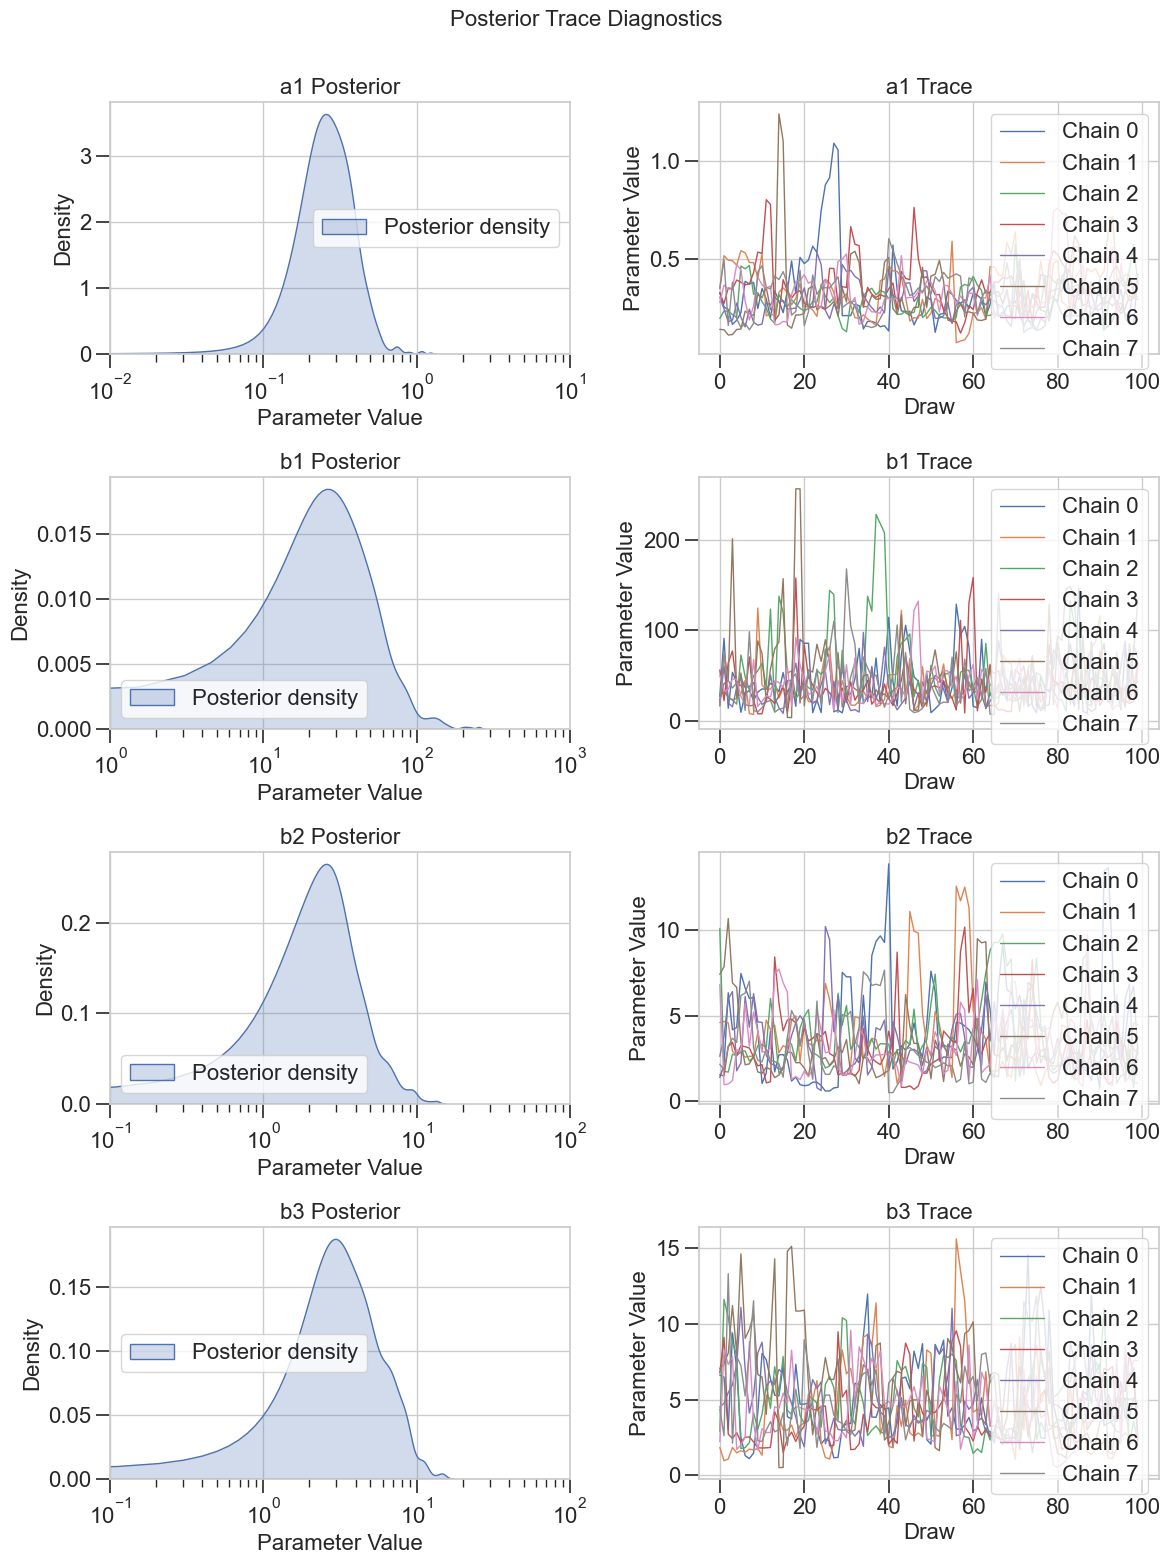

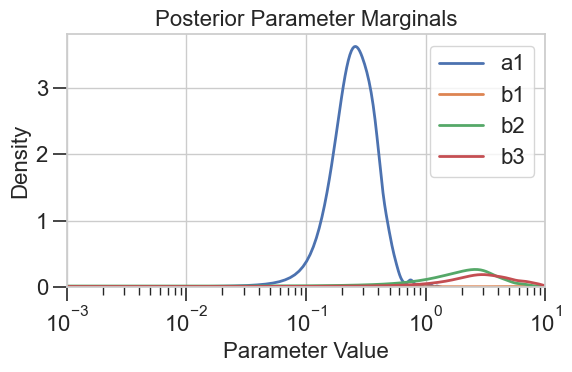

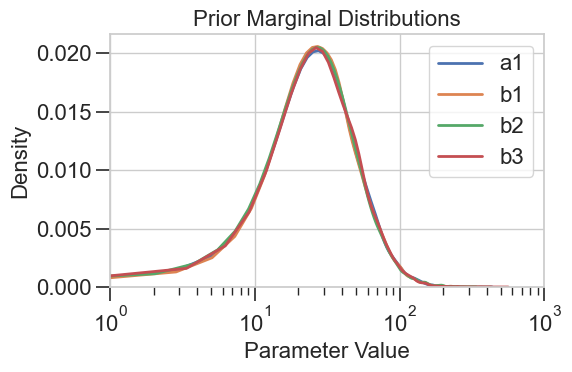

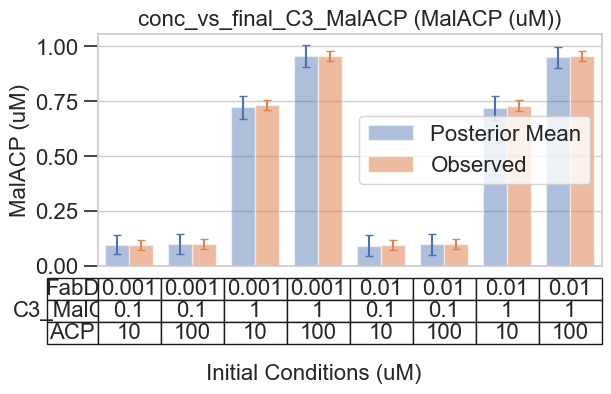

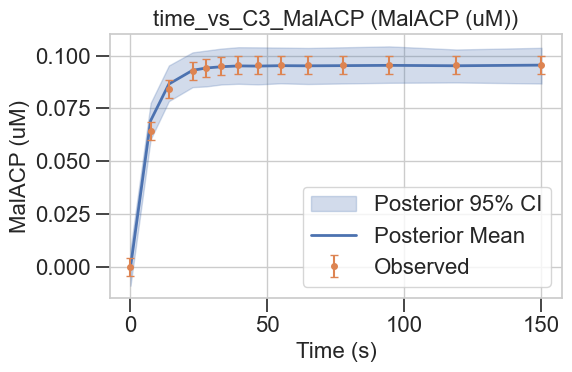

In [2]:
folder_name = "FabD scaling inference" # FabD kon inference | FabD scaling inference

# Toggle workflow mode:
use_existing_results = False
use_log_param_axis = True

# Plot styling
plt.style.use("default")
posterior_plot_color = "C0"
observed_plot_color = "C1"

solver_params_file = f"solver_params.json"
solver_param_path = Path(f"../Results/{folder_name}/{solver_params_file}")
solver_params_dir = solver_param_path.resolve().parent

with open(solver_param_path, "r", encoding="utf-8") as solver_file:
    if solver_param_path.suffix in (".yaml", ".yml"):
        solver_params = yaml.safe_load(solver_file)
    else:
        solver_params = json.load(solver_file)

def resolve_path(base_dir, path_value):
    path = Path(path_value).expanduser()
    if path.is_absolute():
        return path
    return (Path(base_dir) / path).resolve()

def print_section(title):
    print(f"\n=== {title} ===")

def print_item(label, value):
    print(f"- {label}: {value}")

path_base = solver_params.get("path_base", ".")
model_home_dir = resolve_path(solver_params_dir, path_base)

output_paths = solver_params.get("output_paths")
if output_paths is None:
    raise KeyError(
        "solver_params JSON must include an 'output_paths' section. "
        "Regenerate it with guided_solver_config_builder.ipynb."
    )

required_output_path_keys = [
    "reactions_source",
    "results_save_dir",
    "prior_samples_file",
    "posterior_samples_file",
    "trace_plot_file",
]
missing_output_path_keys = [
    key for key in required_output_path_keys if key not in output_paths
]
if missing_output_path_keys:
    raise KeyError(f"Missing output_paths keys: {missing_output_path_keys}")

reactions_source = resolve_path(model_home_dir, output_paths["reactions_source"])
results_save_dir = resolve_path(model_home_dir, output_paths["results_save_dir"])
prior_samples_file = output_paths["prior_samples_file"]
posterior_samples_file = output_paths["posterior_samples_file"]
trace_plot_file = output_paths["trace_plot_file"]

# Ensure output directory exists before writing any results
results_save_dir.mkdir(parents=True, exist_ok=True)

prior_file_path = results_save_dir / prior_samples_file
posterior_file_path = results_save_dir / posterior_samples_file
trace_path = results_save_dir / trace_plot_file
parameter_density_path = trace_path.with_name(f"{trace_path.stem}_hist.pdf")
prior_density_path = trace_path.with_name(f"{trace_path.stem}_prior_hist.pdf")

if not use_existing_results:
    result = run_bayesian_inference(
        solver_params_file=str(solver_param_path),
        reactions_source=output_paths["reactions_source"],
        savedir=output_paths["results_save_dir"],
        prior_samples_file=prior_samples_file,
        posterior_samples_file=posterior_samples_file,
        make_trace_plot=False,
        trace_plot_file=trace_plot_file,
        use_log_param_axis=use_log_param_axis,
    )

    inference_data = result.posterior
    experiment_for_plots = result.experiment
    free_params = result.free_params
    summary_table = result.summary
    loo_result = result.loo
    waic_result = result.waic

    experiment_summary_text = result.experiment_summary
    prior_path_text = result.prior_file
    results_path_text = result.results_file
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)
else:
    if not posterior_file_path.exists():
        raise FileNotFoundError(
            f"Posterior samples file not found: {posterior_file_path}. Set use_existing_results=False to run inference first."
        )

    inference_data = az.from_netcdf(posterior_file_path)

    _, species_names_for_experiment, _, _, _ = build_ode_system_from_reactions(reactions_source)
    experiment_for_plots = load_experiment_bundle(
        solver_params=solver_params,
        solver_params_file=str(solver_param_path),
        species_names=species_names_for_experiment,
    )

    free_params = get_free_parameter_names(solver_params)
    metrics = summarize_inference_metrics(inference_data, free_params)
    free_params = metrics["free_params"]
    summary_table = metrics["summary"]
    loo_result = metrics["loo"]
    waic_result = metrics["waic"]

    experiment_summary_text = "Loaded existing posterior samples (inference run skipped)."
    prior_path_text = str(prior_file_path) if prior_file_path.exists() else "Not found"
    results_path_text = str(posterior_file_path)
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)

print_section("Run Status")
print(experiment_summary_text)

print_section("Files")
print_item("Prior samples", prior_path_text)
print_item("Posterior samples", results_path_text)

print_section("Posterior Summary")
display(summary_table)

print_section("Model Comparison")
print("LOO")
print(loo_result)
print("\nWAIC")
print(waic_result)

trace_artifacts = plot_posterior_trace_diagnostics(
    inf_data=inference_data,
    free_params=free_params,
    save_file=trace_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
parameter_marginal_artifacts = plot_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    save_file=parameter_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
prior_marginal_artifacts = plot_priors(
    inf_data=inference_data,
    free_params=free_params,
    save_file=prior_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
predictive_artifacts = plot_predictive(
    inf_data=inference_data,
    experiment=experiment_for_plots,
    save_dir=str(trace_path.parent),
    file_stem=str(trace_path.stem),
    show=True,
    posterior_color=posterior_plot_color,
    observed_color=observed_plot_color,
 )

print_section("Saved Plots")
if trace_artifacts.get("plot_file"):
    print_item("Trace diagnostics", trace_artifacts["plot_file"])
if parameter_marginal_artifacts.get("plot_file"):
    print_item("Posterior marginals", parameter_marginal_artifacts["plot_file"])
if prior_marginal_artifacts.get("plot_file"):
    print_item("Prior marginals", prior_marginal_artifacts["plot_file"])
elif not prior_marginal_artifacts.get("prior_var_names"):
    print("- Prior marginals: no matching prior variables found")

if predictive_artifacts.get("data_vs_results_plot_files"):
    print_item("Predictive plot count", len(predictive_artifacts["data_vs_results_plot_files"]))
    for dataset_name, plot_path in predictive_artifacts["data_vs_results_plot_files"].items():
        print_item(dataset_name, plot_path)

plot_artifacts = {
    "trace_diagnostics": trace_artifacts,
    "parameter_marginals": parameter_marginal_artifacts,
    "prior_marginals": prior_marginal_artifacts,
    "predictive": predictive_artifacts,
}

---
## Step 3: Diffusion-Limited Effective Parameter Diagnostics

Define effective-parameter limit rules, then evaluate them against the posterior samples already in `inference_data`.

This step is independent of sampling: after changing the limits or patterns below, rerun this cell only. It works with both fresh inference results and `use_existing_results=True`.


=== Diffusion Feasibility ===
- Feasible posterior draws: 800/800 (100.0%)

=== Limited Effective-Parameter Summary ===


,rule_name,rxn_name,direction,param_name,reactants,scale_expr,scale_param_names,lower,upper,n_draws,n_violations,violation_fraction,min_effective,median_effective,max_effective
0,protein_ligand_diffusion_limit,FabD_binding_MalCoA,fwd,kon_D_MalCoA,FabD + C3_MalCoA,None,,-inf,1650.0,800,0,0.0,189.964965,189.964965,189.964965
1,protein_protein_diffusion_limit,FabD_Act_binding_ACP,fwd,kon_D_Act_ACP,C3_FabD_Act + ACP,None,,-inf,629.0,800,0,0.0,77.291995,77.291995,77.291995



=== Posterior Draw Feasibility Summary ===


,draw_index,is_feasible,n_violations,max_violation_ratio,worst_channel,worst_rule
0,0,True,0,0.0,None,None
1,1,True,0,0.0,None,None
2,2,True,0,0.0,None,None
3,3,True,0,0.0,None,None
4,4,True,0,0.0,None,None
5,5,True,0,0.0,None,None
6,6,True,0,0.0,None,None
7,7,True,0,0.0,None,None
8,8,True,0,0.0,None,None
9,9,True,0,0.0,None,None



=== Saved Diffusion Diagnostic Plots ===
- Feasible area marginals: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/FabD scaling inference/trace_plot_diffusion_feasible_marginals.pdf
- Feasible parameter family: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/FabD scaling inference/trace_plot_diffusion_feasible_family.pdf


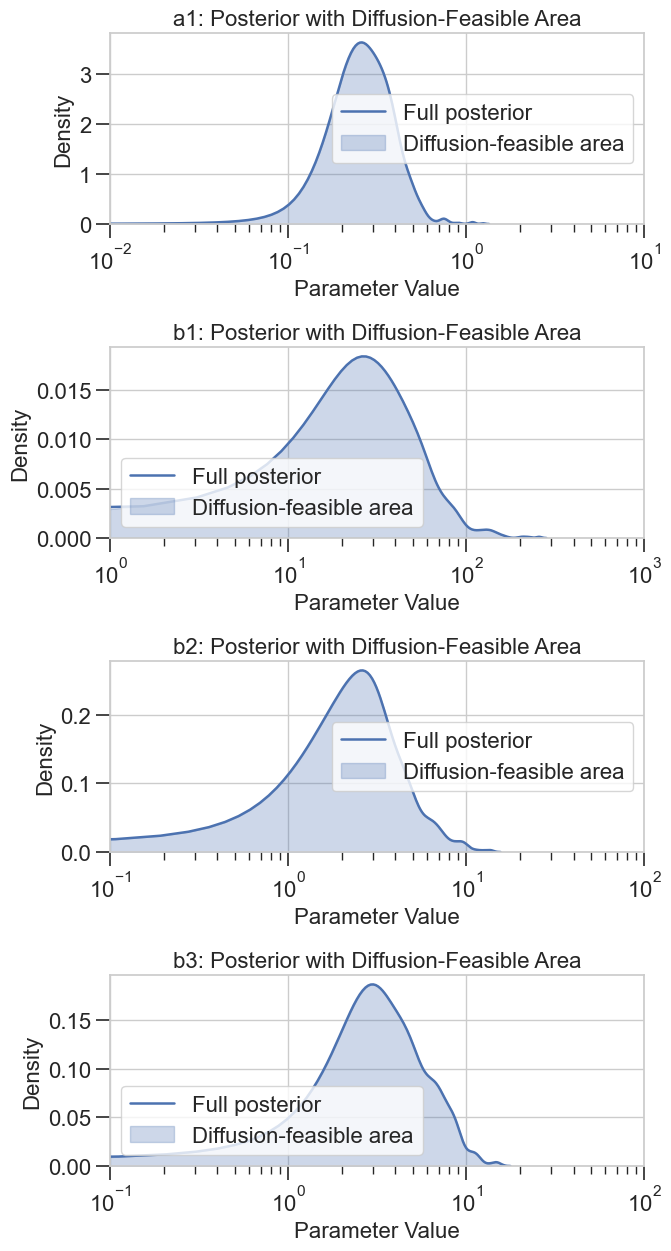

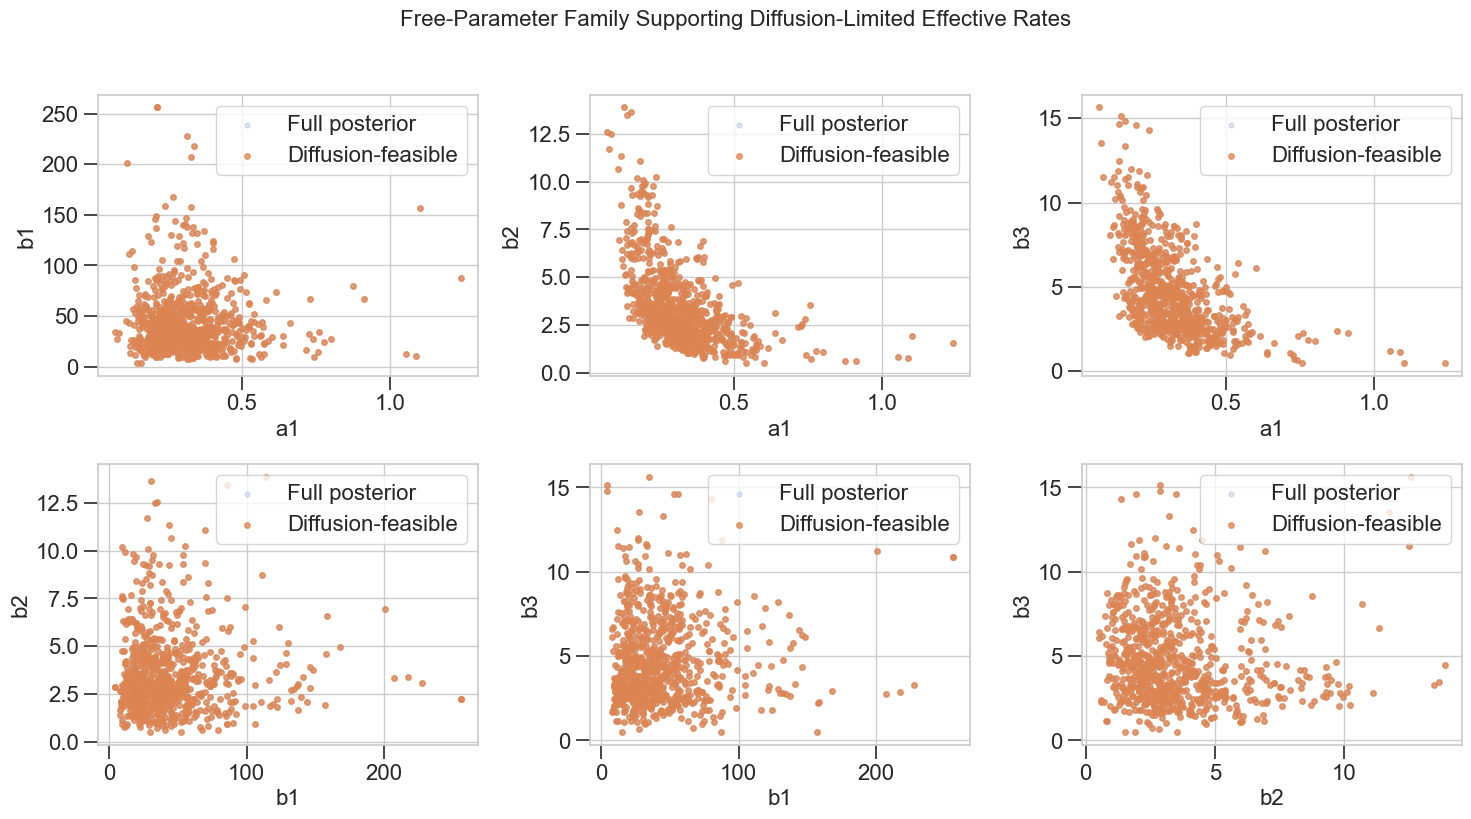

In [3]:
# Edit these rules and rerun this cell to recompute diffusion-limit feasibility.
# Rules are applied to final effective values after scaling: base_parameter * scaling_expression(theta).

protein_pattern = r"Fab[A-Z]|TesA|ACP"
kon_name_pattern = r"(^kon|_k_on_)"

effective_parameter_limits = [
    {
        "name": "protein_protein_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 2,
        "upper": 629.0,
    },
    {
        "name": "protein_ligand_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 1,
        "upper": 1650.0,
    },
    # Exact base-parameter example:
    # {"name": "specific_param_limit", "param_names": ["some_k_on_param"], "lower": 0.0, "upper": 1650.0},
    # Exact scaling-parameter example: checks effective values for every channel whose scale expression uses a1.
    # {"name": "a1_scaled_effective_limit", "param_names": ["a1"], "upper": 1650.0},
    # Scaling-parameter pattern example:
    # {"name": "a_family_scaled_effective_limit", "scaling_param_name_pattern": "^a", "upper": 1650.0},
]

diffusion_limit_result = evaluate_effective_parameter_limits(
    inf_data=inference_data,
    reactions_source=reactions_source,
    free_params=free_params,
    effective_parameter_limits=effective_parameter_limits,
)
diffusion_feasibility_mask = diffusion_limit_result.feasibility_mask

feasible_count = int(np.sum(diffusion_feasibility_mask))
total_count = int(diffusion_feasibility_mask.size)
print_section("Diffusion Feasibility")
print_item("Feasible posterior draws", f"{feasible_count}/{total_count} ({feasible_count / total_count:.1%})")

if diffusion_limit_result.channel_summary.empty:
    print("- Limited effective-parameter summary: no matching reaction channels")
else:
    print_section("Limited Effective-Parameter Summary")
    display(
        diffusion_limit_result.channel_summary.sort_values(
            ["violation_fraction", "max_effective"],
            ascending=[False, False],
        )
    )

print_section("Posterior Draw Feasibility Summary")
display(diffusion_limit_result.draw_summary.head(20))

diffusion_marginal_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_marginals.pdf")
diffusion_family_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_family.pdf")

diffusion_marginal_artifacts = plot_diffusion_feasible_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_marginal_path),
    show=True,
    use_log_param_axis=use_log_param_axis,
)
diffusion_family_artifacts = plot_diffusion_feasible_parameter_family(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_family_path),
    show=True,
)

plot_artifacts["diffusion_feasible_marginals"] = diffusion_marginal_artifacts
plot_artifacts["diffusion_feasible_family"] = diffusion_family_artifacts

print_section("Saved Diffusion Diagnostic Plots")
if diffusion_marginal_artifacts.get("plot_file"):
    print_item("Feasible area marginals", diffusion_marginal_artifacts["plot_file"])
if diffusion_family_artifacts.get("plot_file"):
    print_item("Feasible parameter family", diffusion_family_artifacts["plot_file"])

---
## Step 4: Visualize Prior Distributions

The next cells plot the **prior distributions** for each free parameter — these represent your beliefs about plausible parameter values *before* seeing the data. Compare these to the posterior marginals generated above to see how much the data updated your beliefs.

Each prior is shaped by the `lower`/`upper` bounds and mass % (default 95%) you set in the config builder. The distribution is chosen automatically via maximum entropy (`preliz.maxent`).

Bounds are read directly from `solver_params` so these plots always stay in sync with your config.

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_52537/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


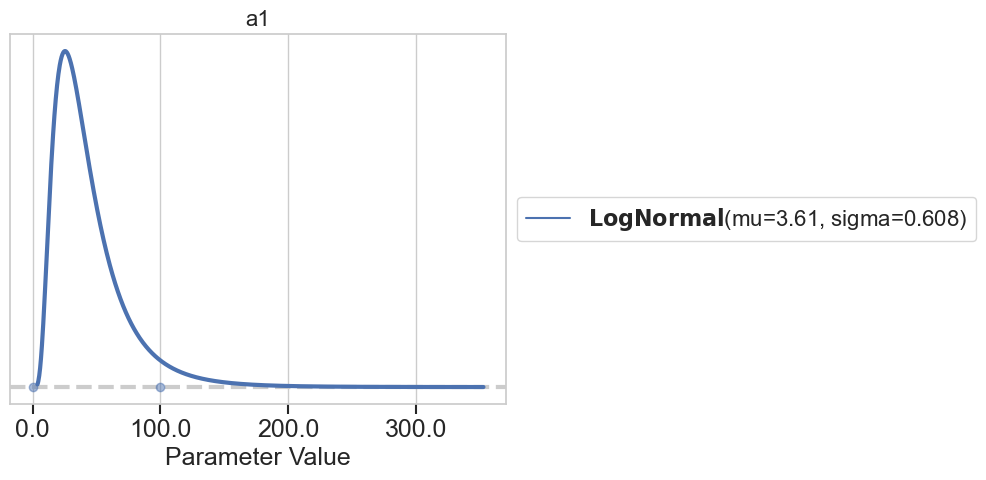

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_52537/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


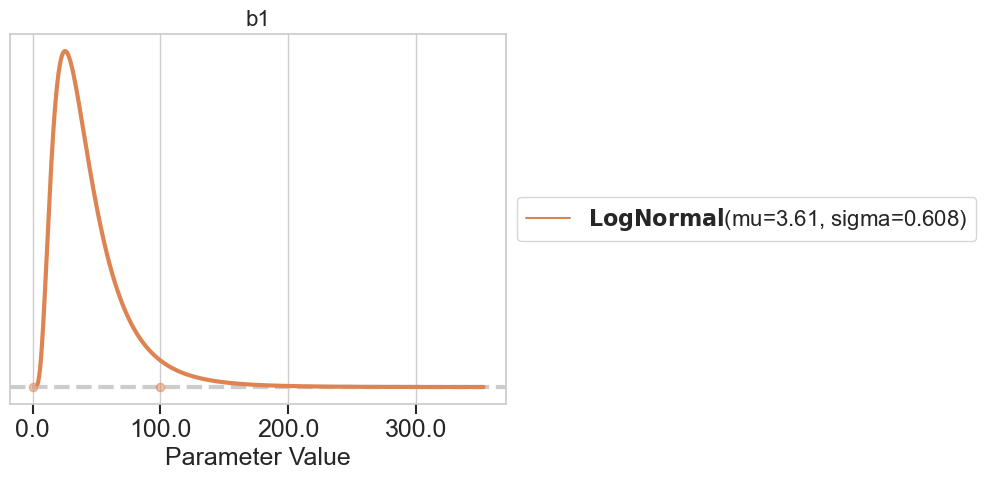

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_52537/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


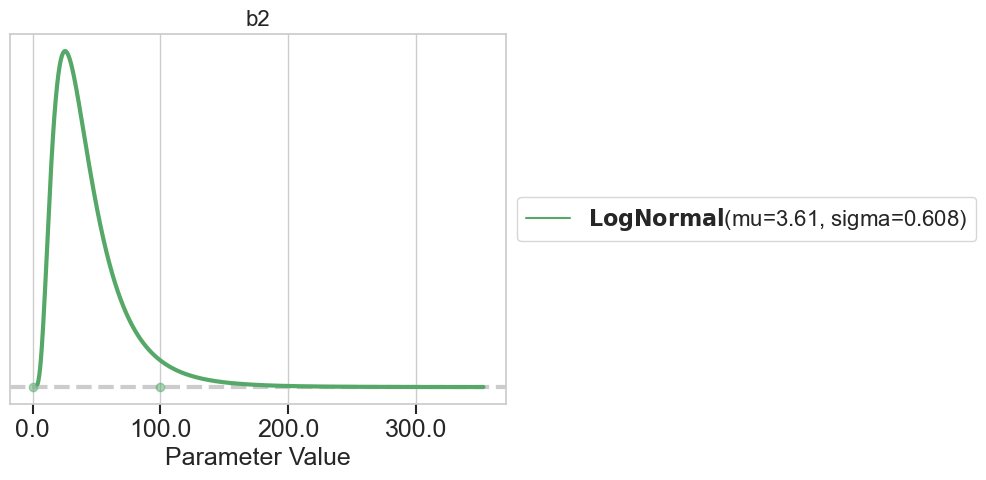

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_52537/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


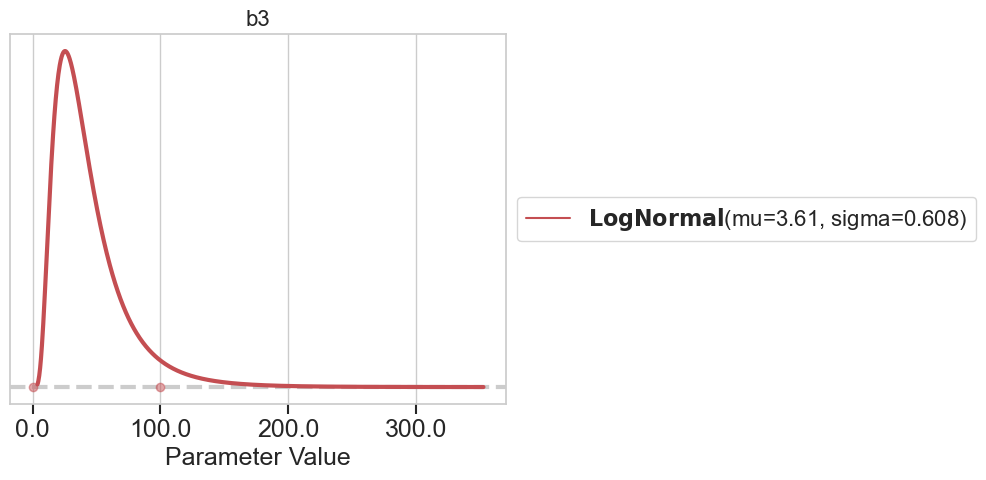

In [4]:
colors = ["C0", "C1", "C2", "C3", "C4"]

for i, param_spec in enumerate(solver_params["free_kinetic_params"]):
    prior_p = param_spec["prior_dist_params"]
    dist = getattr(pz, prior_p["distribution"])()
    result = pz.maxent(
        dist,
        lower=prior_p["lower"],
        upper=prior_p["upper"],
        mass=prior_p.get("mass", 0.95),
        plot=True,
        plot_kwargs={"color": colors[i % len(colors)]},
    )
    ax = plt.gca()
    for line in ax.lines:
        line.set_linewidth(3)
    ax.tick_params(width=1.5, length=7)
    ax.set_xlabel("Parameter Value", fontsize=18)
    ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)
    ax.set_title(param_spec["param_name"], fontsize=16)
    plt.show()